# Benchmark results explorer

Loads `results/results.json` and plots Layer 1 aggregates, per-muscle R², onset timing, and inference resources.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Path to results.json (relative to repo root or absolute)
REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "results" / "results.json").exists() and (REPO_ROOT.parent / "results" / "results.json").exists():
    REPO_ROOT = REPO_ROOT.parent

RESULTS_JSON = REPO_ROOT / "results" / "results.json"

with RESULTS_JSON.open(encoding="utf-8") as fh:
    results = json.load(fh)

meta = results.get("meta", {})
print(f"Loaded {RESULTS_JSON}")
print(f"Samples: {meta.get('n_samples')}  |  device: {meta.get('device')}")

Loaded /Users/maksimpecin/Library/CloudStorage/OneDrive-Личная/Thesis/code/musclemap-bench/results/results.json
Samples: 617  |  device: cpu


In [2]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [3]:
LAYER1_METRICS = [
    ("MAE", "mae"),
    ("RMSE", "rmse"),
    ("DTW MAE", "dtw_mae"),
    ("Pearson r", "pearson_r_mean"),
    ("R² mean", "r2_mean"),
    ("Onset err (frames)", "onset_timing_error_mean"),
    ("Energy ratio", "energy_ratio"),
    ("Co-act Frobenius", "coactivation_frobenius"),
]

layer1 = results.get("layer1", {})
rows = []
for label, key in LAYER1_METRICS:
    row = {"metric": label}
    for method in ("musclemap", "kinesis"):
        branch = layer1.get(method, {})
        row[method] = branch.get(key)
    rows.append(row)

summary_df = pd.DataFrame(rows).set_index("metric")
display(summary_df)

,musclemap,kinesis
metric,,
MAE,4.532371e-02,0.013647
RMSE,6.577687e-02,0.017943
DTW MAE,4.532371e-02,0.013647
Pearson r,-5.862056e-10,0.000000
R² mean,-2.166834e+04,-532227.206995
Onset err (frames),4.259783e+01,NaN
Energy ratio,1.471904e+01,0.000000
Co-act Frobenius,7.728627e+01,NaN


## Paired comparison (same sequences, same leg muscles)

Only clips with Kinesis precompute artifacts. Requires `layer1_paired` in `results.json` (re-run benchmark after updating `run_benchmark.py`).

In [ ]:
paired = results.get("layer1_paired", {})
if not paired.get("musclemap", {}).get("mae"):
    print("No layer1_paired in results — run: python scripts/run_benchmark.py --config config.yaml")
else:
    n_seq = paired.get("n_sequences", paired["musclemap"].get("n_samples"))
    print(f"Paired sequences: {n_seq}  |  muscles: {paired.get('n_muscles')}")
    rows = []
    for label, key in LAYER1_METRICS:
        rows.append({
            "metric": label,
            "musclemap": paired["musclemap"].get(key),
            "kinesis": paired["kinesis"].get(key),
        })
    paired_df = pd.DataFrame(rows).set_index("metric")
    display(paired_df)

    labels = [m[0] for m in LAYER1_METRICS[:3]]
    keys = [m[1] for m in LAYER1_METRICS[:3]]
    x = np.arange(len(labels))
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(x - 0.2, [paired["musclemap"].get(k) for k in keys], width=0.4, label="MuscleMAP")
    ax.bar(x + 0.2, [paired["kinesis"].get(k) for k in keys], width=0.4, label="Kinesis")
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_title(f"Paired Layer 1 (n={n_seq} sequences, mapped leg muscles)")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

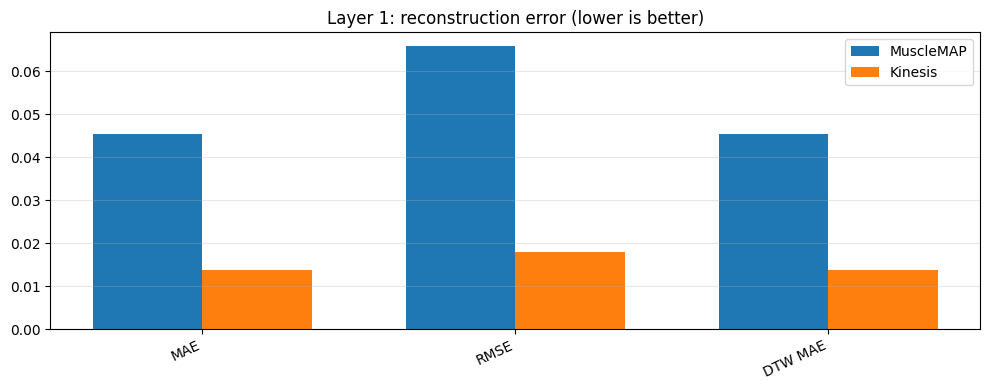

In [4]:
def _bar_compare(metric_keys: list[tuple[str, str]], title: str) -> None:
    labels = [m[0] for m in metric_keys]
    keys = [m[1] for m in metric_keys]
    mm_vals = [layer1.get("musclemap", {}).get(k) for k in keys]
    kin_vals = [layer1.get("kinesis", {}).get(k) for k in keys]

    x = np.arange(len(labels))
    width = 0.35
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(x - width / 2, [v if v is not None else np.nan for v in mm_vals], width, label="MuscleMAP")
    ax.bar(x + width / 2, [v if v is not None else np.nan for v in kin_vals], width, label="Kinesis")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=25, ha="right")
    ax.set_title(title)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


_bar_compare(
    [("MAE", "mae"), ("RMSE", "rmse"), ("DTW MAE", "dtw_mae")],
    "Layer 1: reconstruction error (lower is better)",
)

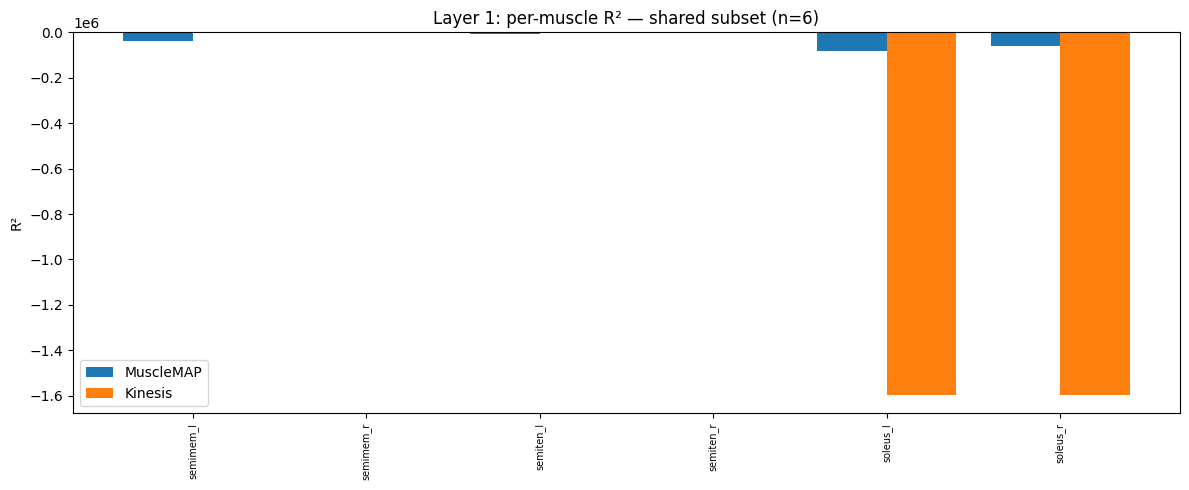

In [5]:
mm_r2 = layer1.get("musclemap", {}).get("r2_per_muscle_named", {})
kin_r2 = layer1.get("kinesis", {}).get("r2_per_muscle_named", {})

if not mm_r2:
    print("No per-muscle R² in results.")
else:
    # For Kinesis, plot only muscles present in both dicts
    if kin_r2:
        names = sorted(set(mm_r2) & set(kin_r2))
        mm_vals = [mm_r2[n] for n in names]
        kin_vals = [kin_r2[n] for n in names]
        title_suffix = f"shared subset (n={len(names)})"
    else:
        names = sorted(mm_r2)
        mm_vals = [mm_r2[n] for n in names]
        kin_vals = None
        title_suffix = "MuscleMAP (all muscles)"

    x = np.arange(len(names))
    fig, ax = plt.subplots(figsize=(max(12, 0.25 * len(names)), 5))
    ax.bar(x - 0.2, mm_vals, width=0.4, label="MuscleMAP")
    if kin_vals is not None:
        ax.bar(x + 0.2, kin_vals, width=0.4, label="Kinesis")
    ax.axhline(0, color="gray", linewidth=0.5)
    ax.set_ylabel("R²")
    ax.set_title(f"Layer 1: per-muscle R² — {title_suffix}")
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=90, fontsize=7)
    ax.legend()
    plt.tight_layout()
    plt.show()

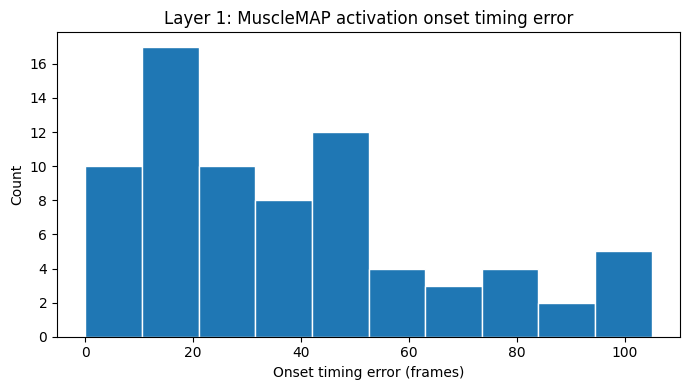

In [6]:
onset = layer1.get("musclemap", {}).get("onset_timing_errors_all", [])
if not onset:
    print("No onset_timing_errors_all in results.")
else:
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(onset, bins=min(30, max(10, len(onset) // 20)), edgecolor="white")
    ax.set_xlabel("Onset timing error (frames)")
    ax.set_ylabel("Count")
    ax.set_title("Layer 1: MuscleMAP activation onset timing error")
    plt.tight_layout()
    plt.show()

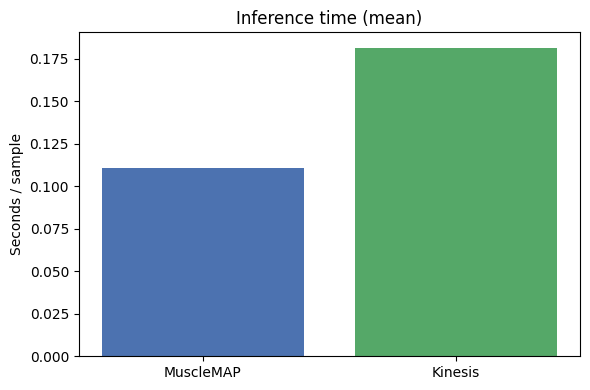

In [7]:
resources = results.get("resources", {})
methods = ["musclemap", "kinesis", "motiongpt"]
labels = ["MuscleMAP", "Kinesis", "MotionGPT"]
mean_s = [
    resources.get(m, {}).get("inference", {}).get("mean_s")
    for m in methods
]

fig, ax = plt.subplots(figsize=(6, 4))
valid = [(lbl, v) for lbl, v in zip(labels, mean_s) if v is not None]
if valid:
    lbls, vals = zip(*valid)
    ax.bar(lbls, vals, color=["#4c72b0", "#55a868", "#c44e52"][: len(lbls)])
    ax.set_ylabel("Seconds / sample")
    ax.set_title("Inference time (mean)")
    plt.tight_layout()
    plt.show()
else:
    print("No inference timings recorded.")

In [8]:
layer2 = results.get("layer2", {})
mm_l2 = layer2.get("musclemap", {})
mg_l2 = layer2.get("motiongpt", {})
has_l2 = mm_l2.get("fid_mean") is not None or mg_l2.get("fid_mean") is not None

if not has_l2:
    print("Layer 2 not computed (empty musclemap / motiongpt blocks).")
else:
    L2 = [("FID", "fid_mean"), ("R@1", "r_precision_top1"), ("MM-Dist", "mm_dist"), ("Diversity", "diversity")]
    labels = [m[0] for m in L2]
    keys = [m[1] for m in L2]
    x = np.arange(len(labels))
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(x - 0.2, [mm_l2.get(k) for k in keys], width=0.4, label="MuscleMAP")
    ax.bar(x + 0.2, [mg_l2.get(k) for k in keys], width=0.4, label="MotionGPT")
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_title("Layer 2: HumanML3D-style metrics")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

Layer 2 not computed (empty musclemap / motiongpt blocks).
